In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import h5py
import scipy.sparse as sp
import yaml
import scanpy as sc
import scanpy.external as sce
import gget
import time
import pyranges as pr

import logging

In [2]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()
adata

Memory usage: current 3.30 GB, difference +3.30 GB


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

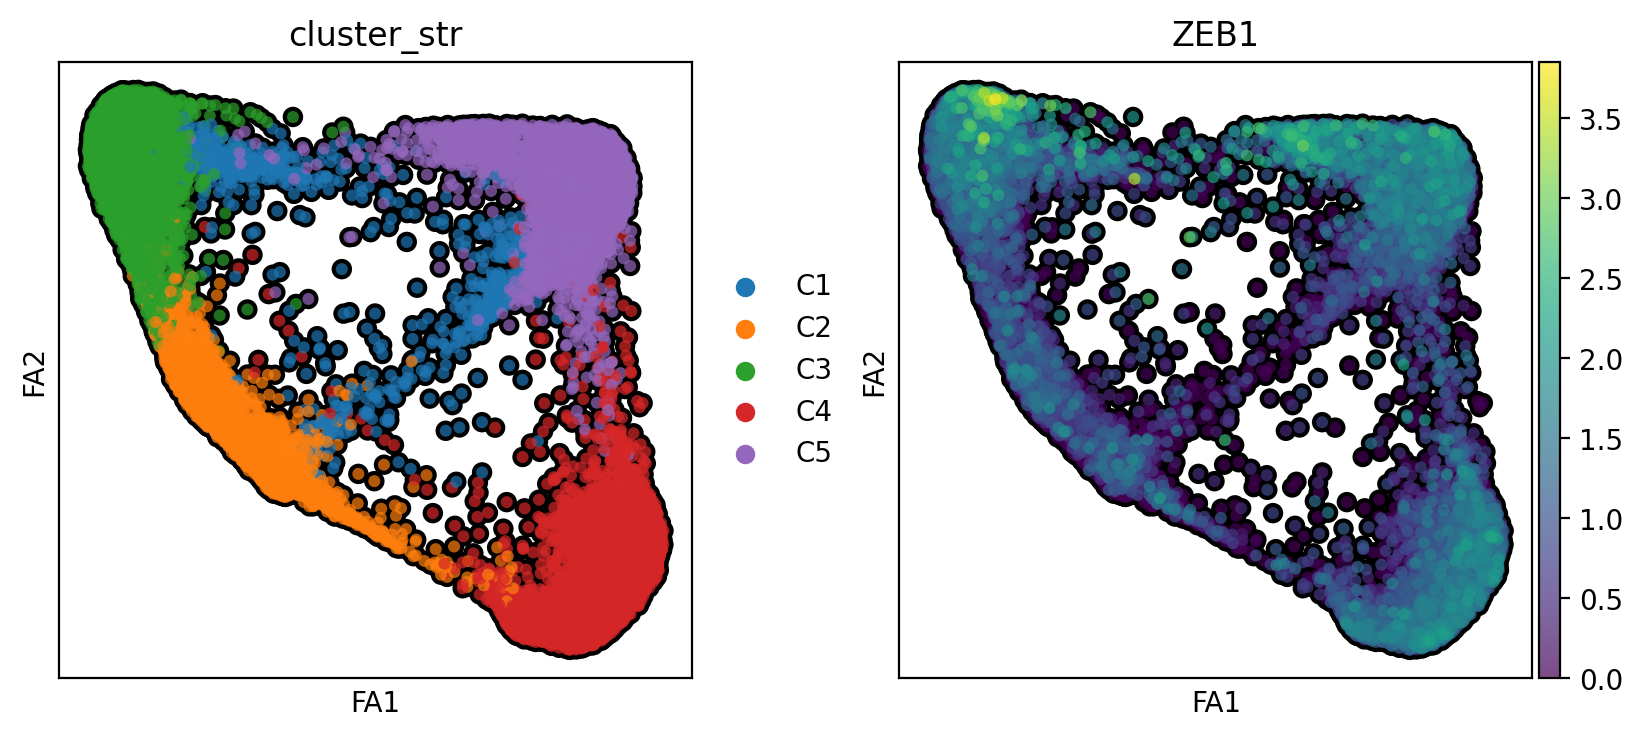

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    color=['cluster_str', 'ZEB1',],
    size=75,
    ncols=2,
    use_raw=False,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
)

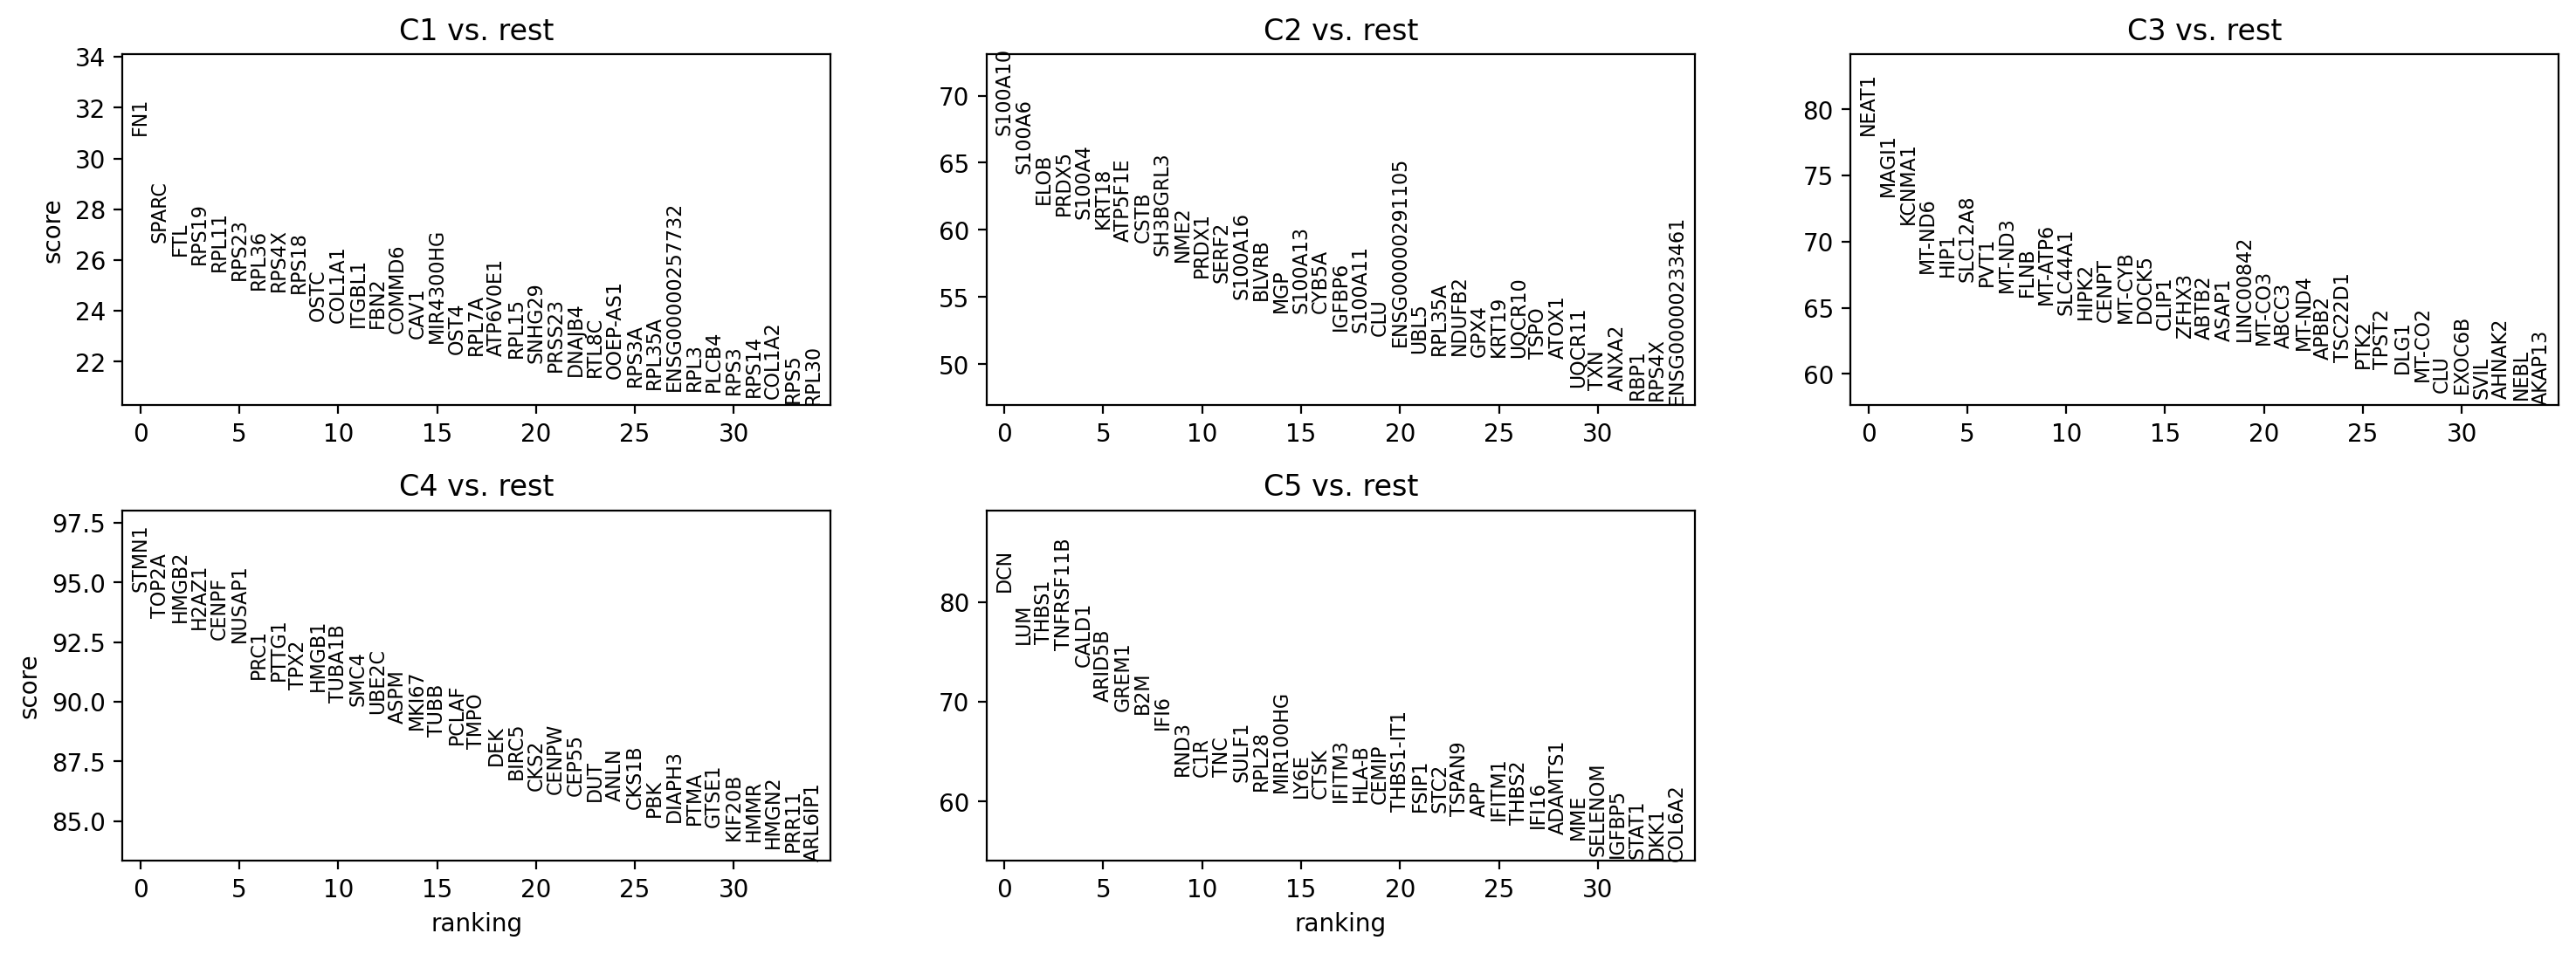

CPU times: user 26.4 s, sys: 14.9 s, total: 41.3 s
Wall time: 14.3 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C1,FN1,30.910458,2.040230,8.642936e-210,1.850626e-205,0.994005,0.950642
1,C1,SPARC,26.696173,0.978468,5.213877e-157,1.860659e-153,0.994005,0.978980
2,C1,FTL,26.184055,1.032066,4.037250e-151,1.234937e-147,0.995204,0.994678
3,C1,RPS19,25.824425,0.482341,4.715831e-147,1.262192e-143,0.996403,0.996142
4,C1,RPL11,25.576998,0.464369,2.750674e-144,6.544160e-141,0.990408,0.990222


In [4]:
%%time
sc.tl.rank_genes_groups(
    adata, 
    groupby='cluster_str',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
    
)

deg.head()

In [5]:
deg[deg['names'] == 'ZEB1']

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
4156,C1,ZEB1,-5.612086,-0.362998,1.999018e-08,2.312424e-07,0.654676,0.669993
12981,C2,ZEB1,-35.610558,-1.680533,9.617079e-278,8.652139e-276,0.365025,0.729318
24940,C4,ZEB1,16.990385,0.438881,9.675200e-65,1.054277e-63,0.806751,0.616170
33452,C5,ZEB1,13.080155,0.402426,4.275679e-39,4.280076e-38,0.701572,0.655525


In [6]:
group_map = {
    'C1' : pd.NA,
    'C2' : 'R',
    'C3' : 'R',
    'C4' : 'I',
    'C5' : 'I',
}
adata.obs['group'] = adata.obs['cluster_str'].map(group_map)
adata.obs['group'].value_counts(dropna=False)

group
I       9122
R       5911
<NA>     834
Name: count, dtype: int64

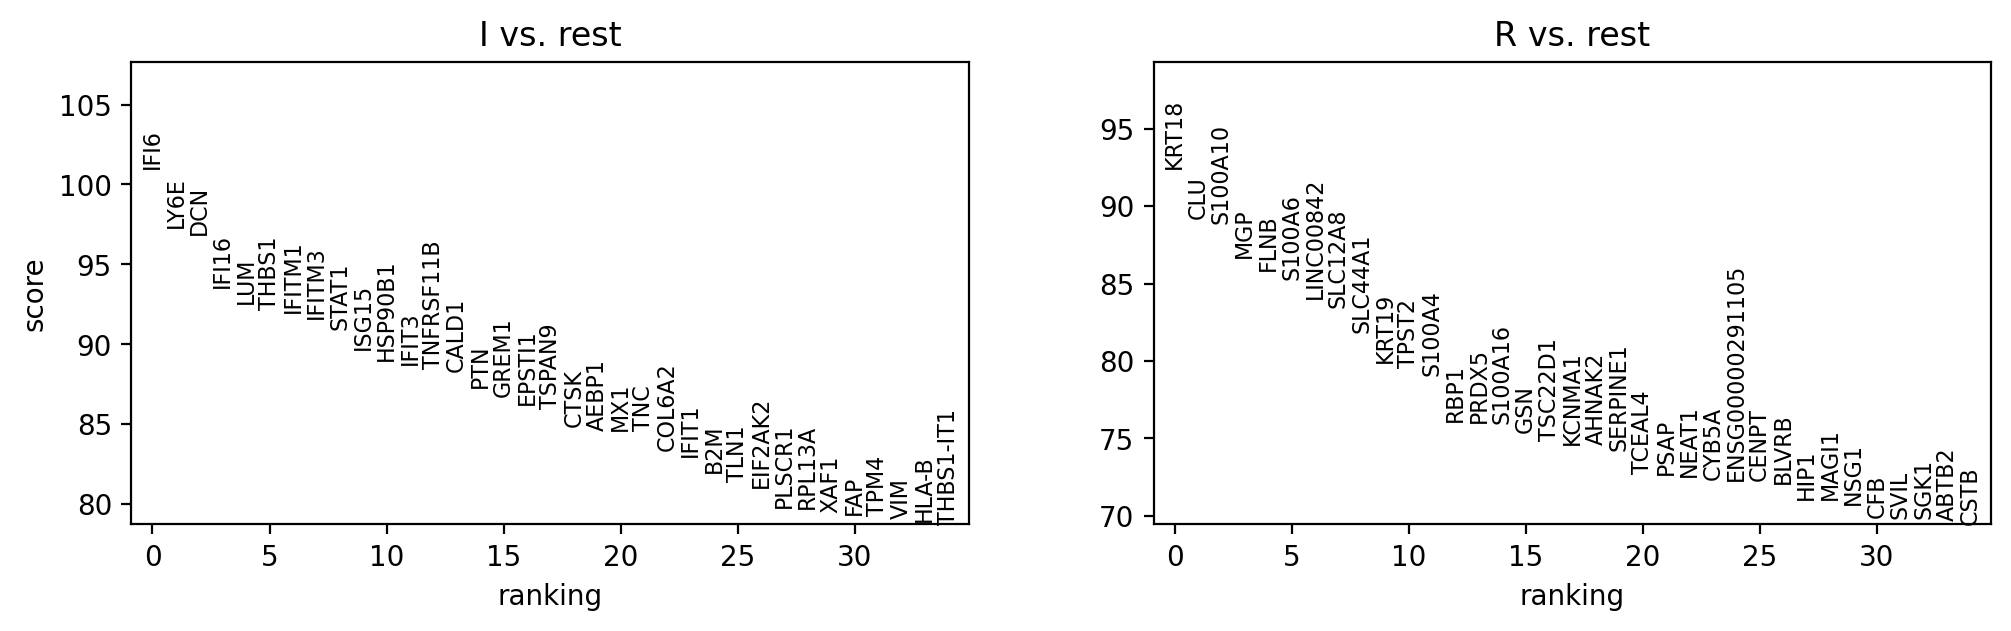

CPU times: user 24.5 s, sys: 13.4 s, total: 37.9 s
Wall time: 11.4 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,I,IFI6,100.965279,5.434073,0.0,0.0,0.969524,0.461379
1,I,LY6E,97.310684,2.864794,0.0,0.0,0.985201,0.714455
2,I,DCN,96.880852,5.223413,0.0,0.0,0.952861,0.185174
3,I,IFI16,93.546204,4.487603,0.0,0.0,0.925126,0.234248
4,I,LUM,92.523422,4.648037,0.0,0.0,0.932800,0.144107


In [7]:
%%time
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()

In [8]:
deg[deg['names'] == 'ZEB1']

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
818,I,ZEB1,27.48749,0.746761,2.477439e-166,3.955774e-165,0.752467,0.556560
20212,R,ZEB1,-25.51560,-0.714244,1.323277e-143,2.012359e-142,0.542717,0.744275


In [9]:
gene_list = ["TP53",
"YAP1",
"TEAD1",
"TEAD4",
"REST",
]

print(deg[deg['names'].isin(gene_list) ].to_string())

      group  names     scores  logfoldchanges          pvals      pvals_adj  pct_nz_group  pct_nz_reference
1246      I  TEAD1  20.246811        0.511909   3.789927e-91   3.753465e-90      0.820763          0.665827
2605      I   YAP1   8.605314        0.277908   7.610806e-18   3.108786e-17      0.562596          0.463603
4971      I   TP53  -2.485754       -0.196334   1.292773e-02   2.689029e-02      0.261237          0.277687
6871      I   REST  -5.227112       -0.266643   1.721778e-07   5.094199e-07      0.375576          0.404003
14248     R   REST   5.129729        0.283745   2.901597e-07   8.815124e-07      0.401117          0.379671
18539     R   YAP1  -8.988968       -0.292413   2.495623e-19   1.110018e-18      0.451362          0.561571
20004     R  TEAD1 -21.926388       -0.575566  1.455349e-106  1.738947e-105      0.645745          0.819707


In [10]:
[x for x in adata.var_names if x in gene_list

SyntaxError: incomplete input (391286630.py, line 1)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata,
    color=['cluster_str'] + gene_list,
    size=75,
    ncols=2,
    use_raw=False,
    layer='log_norm',
    add_outline=True,
    outline_color=('k', 'k'),
)